# Leukemia Dataset — Complete ML Pipeline
> **Author:** Vinayak Vivek Joshi  
> **Dataset:** leukemia.csv — 143,194 patient records, 21 features + 1 target  
> **Task:** Binary Classification — `Leukemia_Status` (Positive / Negative)  
> **Models:** Logistic Regression · Decision Tree · Random Forest

## 1. Setup & Imports

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded')

Libraries loaded


## 2. Load Data

In [232]:
df = pd.read_csv('leukemia.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (143194, 22)


,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,...,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,1,52,Male,China,2698,5.36,262493,12.2,72,Yes,...,No,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative
1,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,...,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive
2,3,72,Male,France,9614,5.17,319600,13.4,94,No,...,Yes,No,No,27.7,No,No,Ethnic_Group_B,Low,Urban,Negative
3,4,61,Male,Brazil,6278,5.41,215200,11.6,50,No,...,No,No,No,31.6,No,No,Ethnic_Group_A,Medium,Rural,Negative
4,5,21,Male,Brazil,8342,4.78,309169,14.3,28,No,...,No,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative


## 3. Dataset Overview & Quality Check

In [233]:
df.info()
print(f'\nTotal missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows       : {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Patient_ID            143194 non-null  int64  
 1   Age                   143194 non-null  int64  
 2   Gender                143194 non-null  object 
 3   Country               143194 non-null  object 
 4   WBC_Count             143194 non-null  int64  
 5   RBC_Count             143194 non-null  float64
 6   Platelet_Count        143194 non-null  int64  
 7   Hemoglobin_Level      143194 non-null  float64
 8   Bone_Marrow_Blasts    143194 non-null  int64  
 9   Genetic_Mutation      143194 non-null  object 
 10  Family_History        143194 non-null  object 
 11  Smoking_Status        143194 non-null  object 
 12  Alcohol_Consumption   143194 non-null  object 
 13  Radiation_Exposure    143194 non-null  object 
 14  Infection_History     143194 non-null  object 
 15  

In [234]:
df.describe()

,Patient_ID,Age,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,BMI
count,143194.00000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000
mean,71597.50000,44.945200,7001.289879,4.998193,249933.012137,13.498334,49.547984,24.990679
std,41336.69156,25.737805,2007.444410,0.500298,49842.308243,1.996714,28.837607,4.999786
min,1.00000,1.000000,-1602.000000,2.940000,46069.000000,4.700000,0.000000,2.800000
25%,35799.25000,23.000000,5644.250000,4.660000,216372.000000,12.100000,25.000000,21.600000
50%,71597.50000,45.000000,7007.000000,5.000000,250248.500000,13.500000,50.000000,25.000000
75%,107395.75000,67.000000,8352.000000,5.340000,283603.500000,14.800000,75.000000,28.300000
max,143194.00000,89.000000,15586.000000,7.150000,460325.000000,22.200000,99.000000,49.100000


In [235]:
target_counts = df['Leukemia_Status'].value_counts()
print(target_counts)
ratio = target_counts['Negative'] / target_counts['Positive']
print(f'\nClass imbalance ratio (Neg : Pos) = {ratio:.1f} : 1')

Leukemia_Status
Negative    121797
Positive     21397
Name: count, dtype: int64

Class imbalance ratio (Neg : Pos) = 5.7 : 1


## 4. Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis — Numerical Features

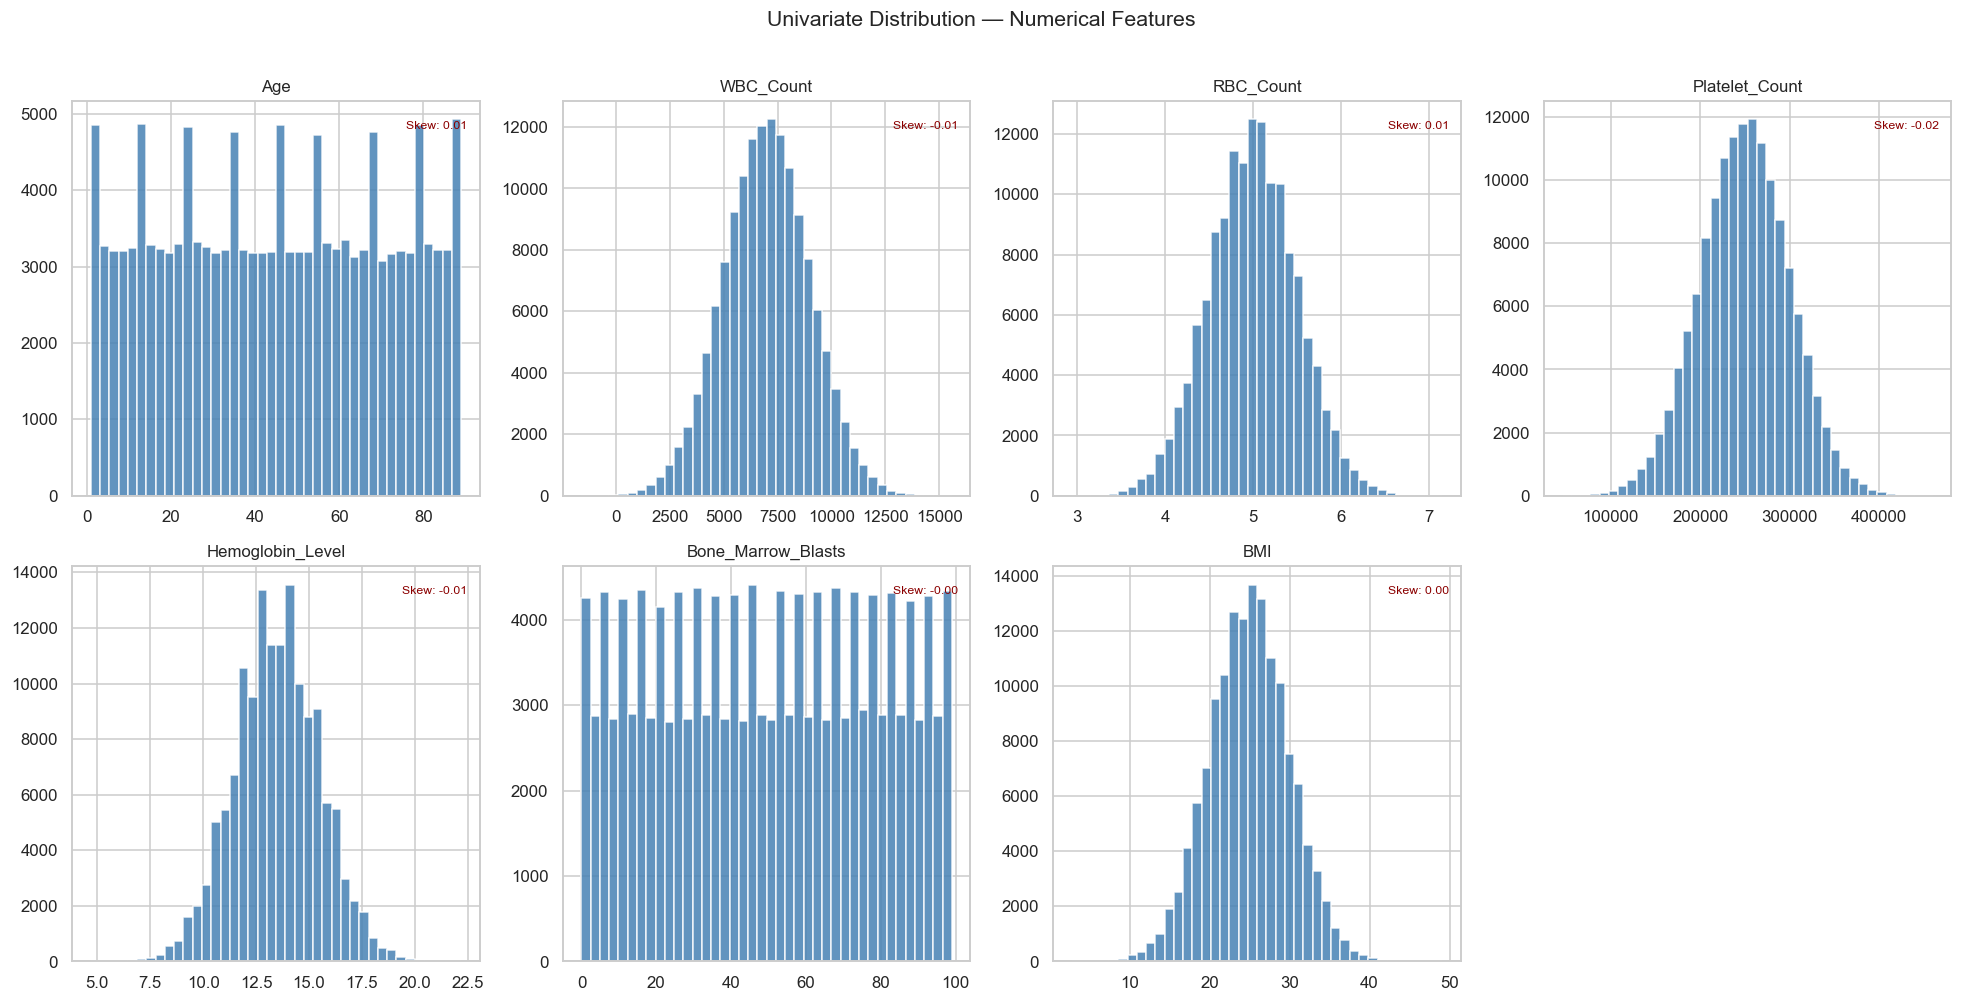

In [236]:
num_cols = ['Age', 'WBC_Count', 'RBC_Count', 'Platelet_Count',
            'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'BMI']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    skew_val = df[col].skew()
    axes[i].text(0.97, 0.95, f'Skew: {skew_val:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8, color='darkred')

axes[-1].axis('off')
fig.suptitle('Univariate Distribution — Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Univariate Analysis — Categorical Features

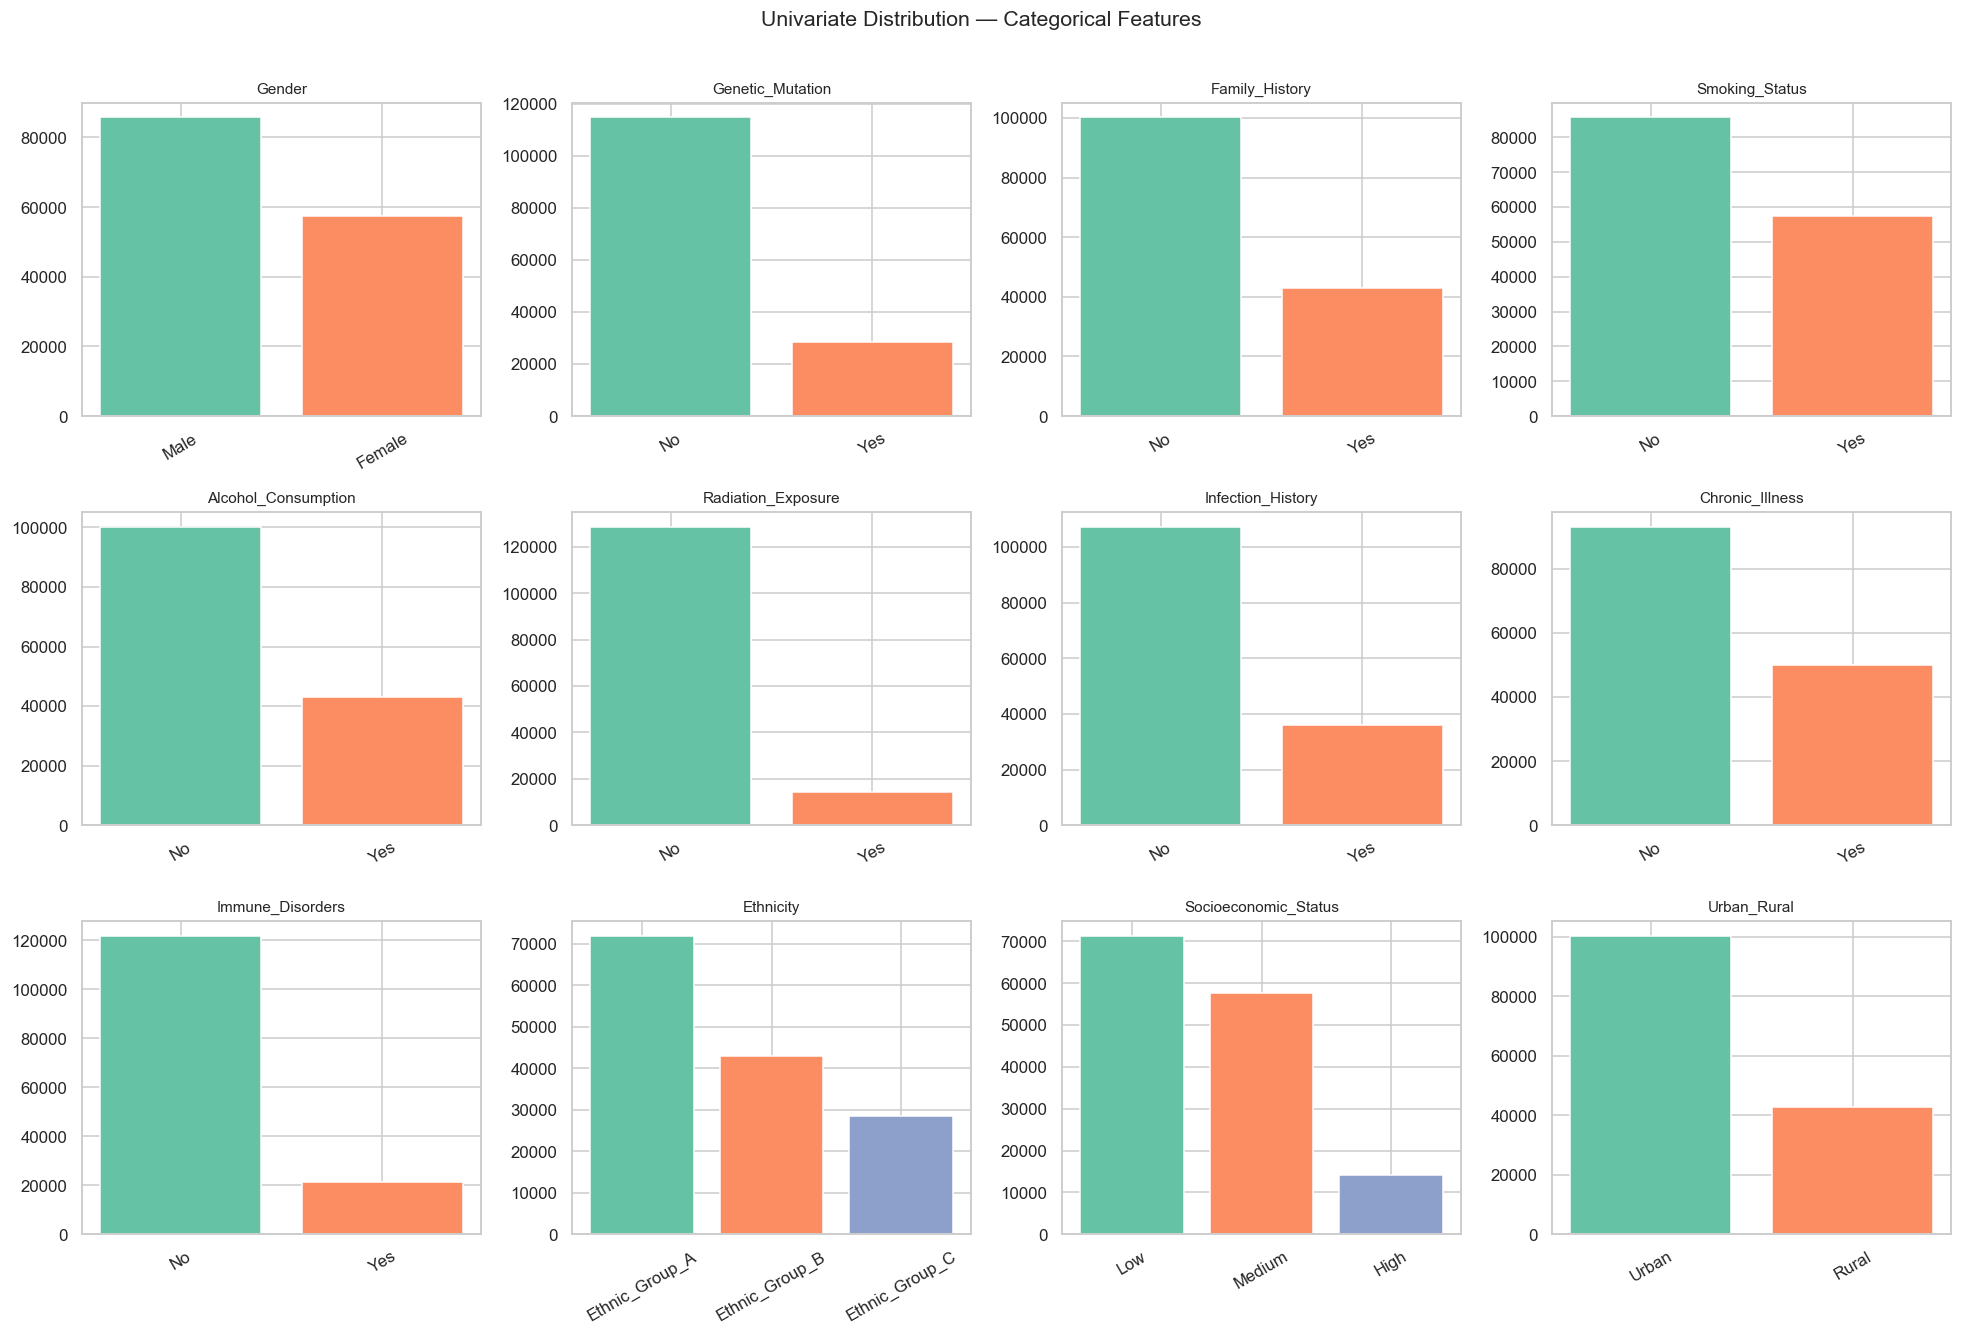

In [237]:
cat_cols = ['Gender', 'Genetic_Mutation', 'Family_History', 'Smoking_Status',
            'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History',
            'Chronic_Illness', 'Immune_Disorders', 'Ethnicity',
            'Socioeconomic_Status', 'Urban_Rural']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Univariate Distribution — Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Bivariate Analysis — Numerical vs Target

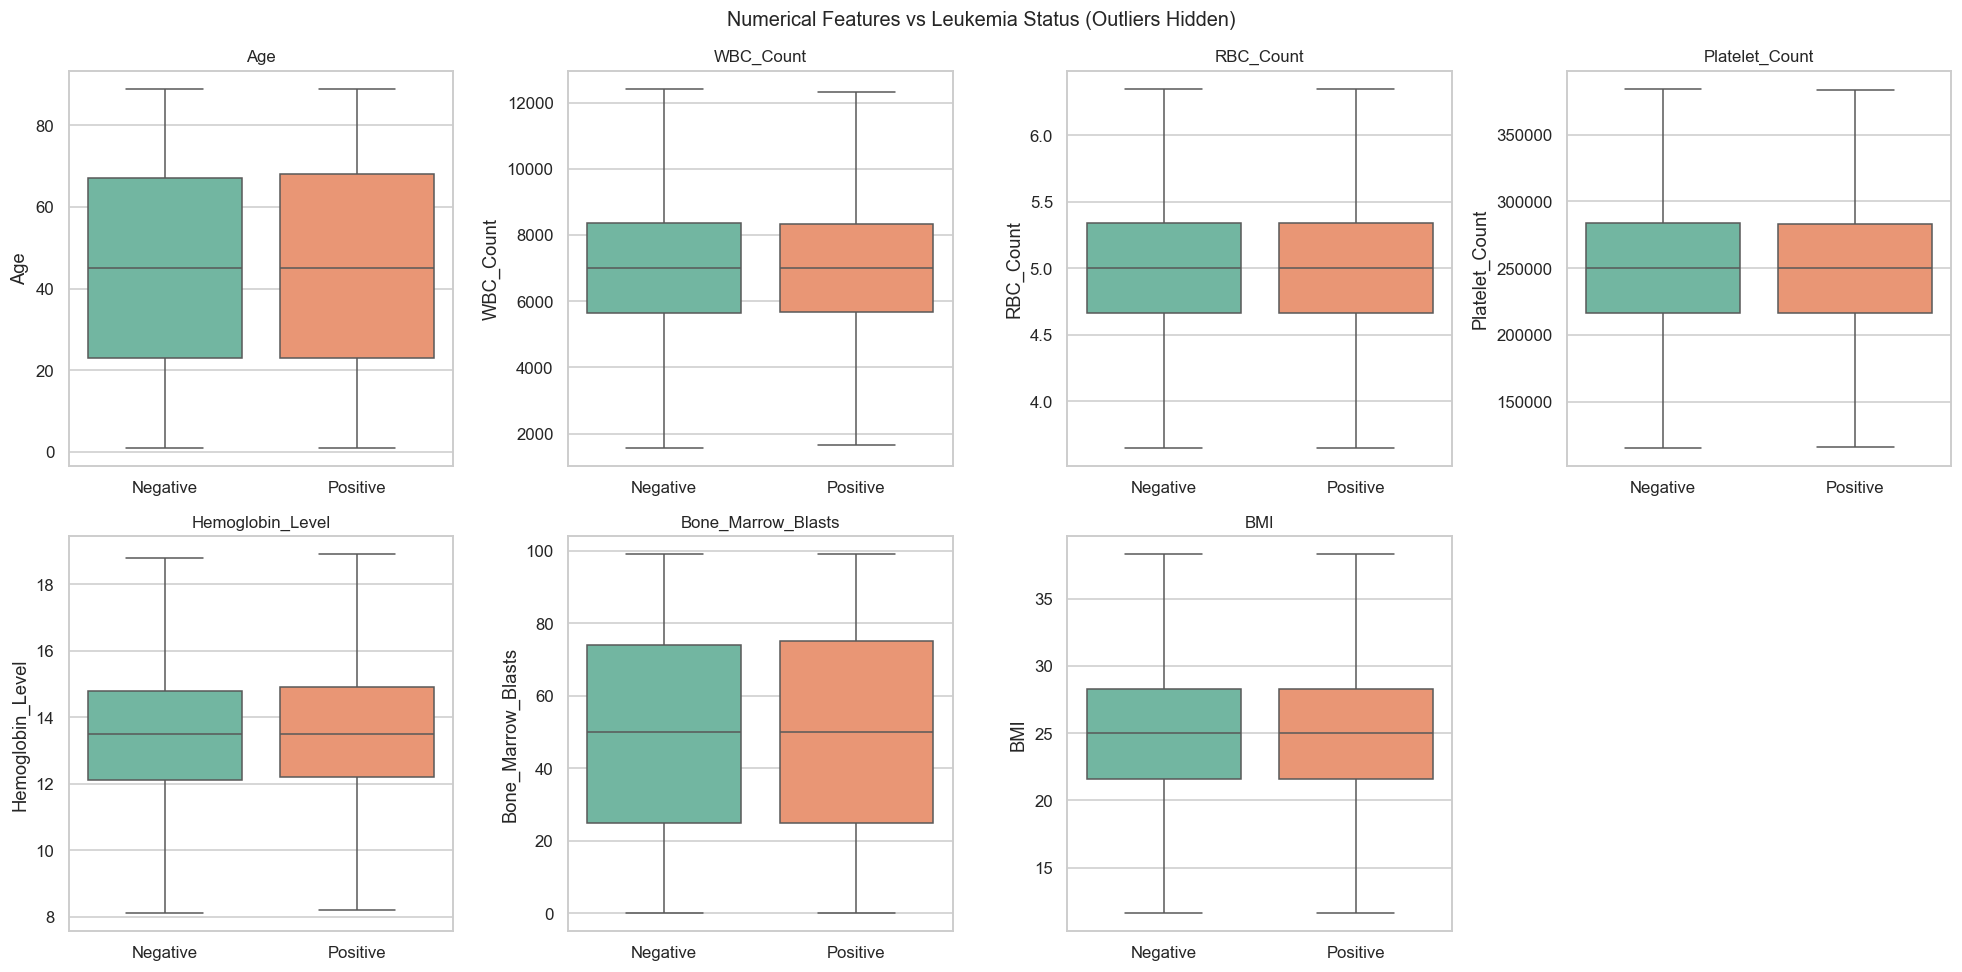

In [238]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Leukemia_Status', y=col,
                palette='Set2', ax=axes[i], showfliers=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

axes[-1].axis('off')
fig.suptitle('Numerical Features vs Leukemia Status (Outliers Hidden)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Bivariate Analysis — Categorical vs Target

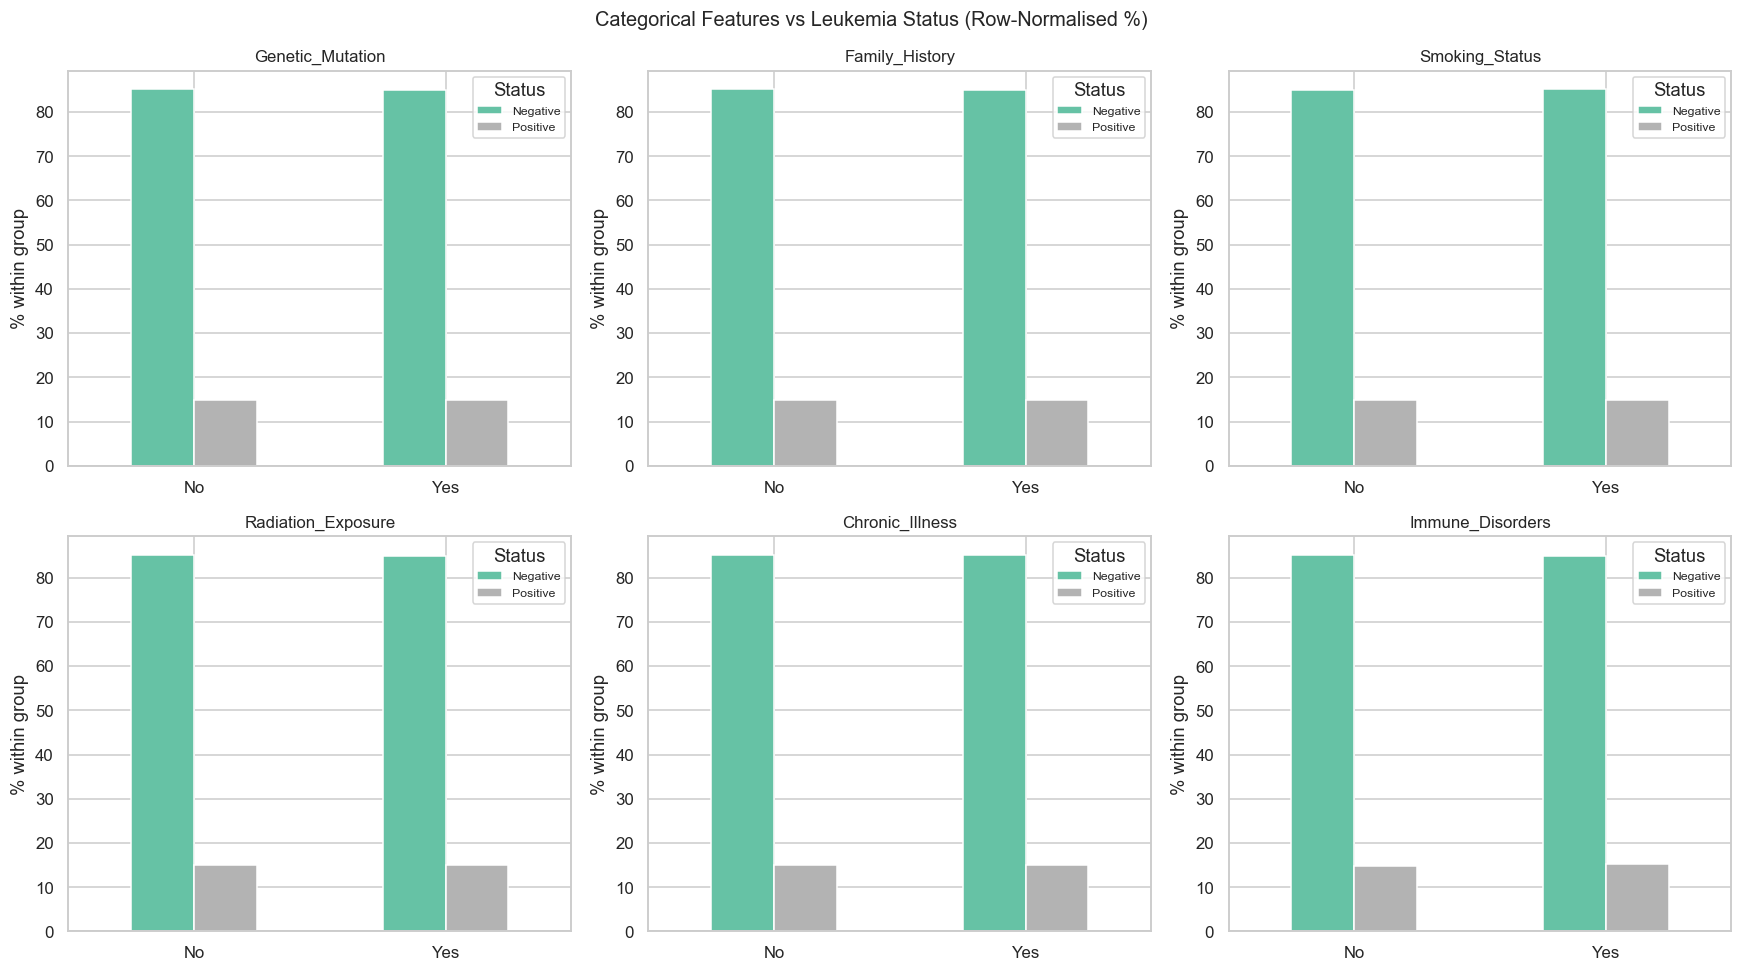

In [239]:
key_cats = ['Genetic_Mutation', 'Family_History', 'Smoking_Status',
            'Radiation_Exposure', 'Chronic_Illness', 'Immune_Disorders']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ct = pd.crosstab(df[col], df['Leukemia_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white', rot=0)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('% within group')
    axes[i].legend(title='Status', fontsize=8)
    axes[i].set_xlabel('')

fig.suptitle('Categorical Features vs Leukemia Status (Row-Normalised %)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Multivariate Analysis — Correlation Heatmap

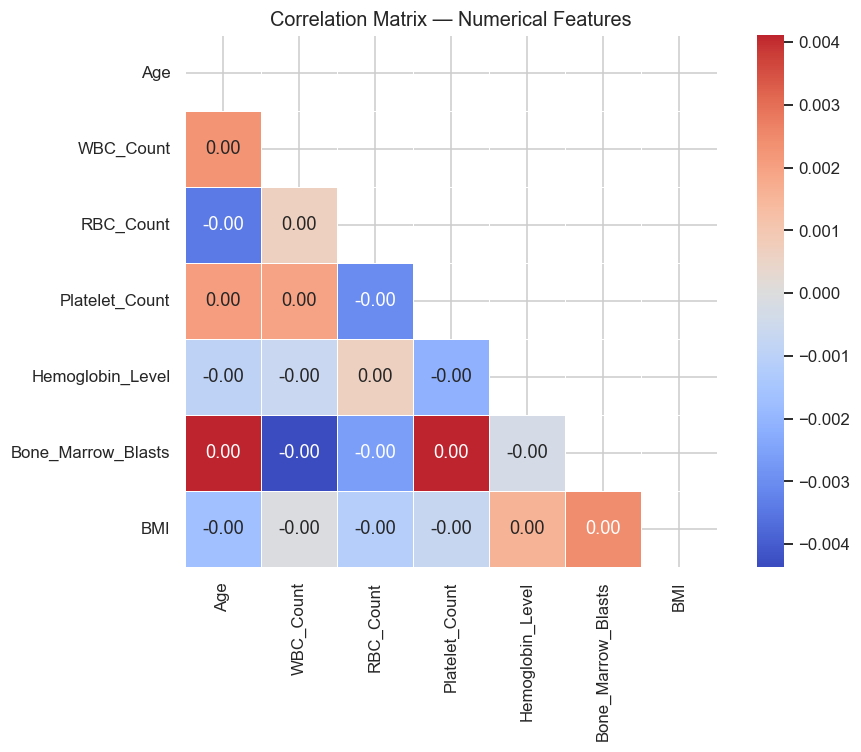

In [240]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

### 4.6 Pairplot — Key Numerical Features

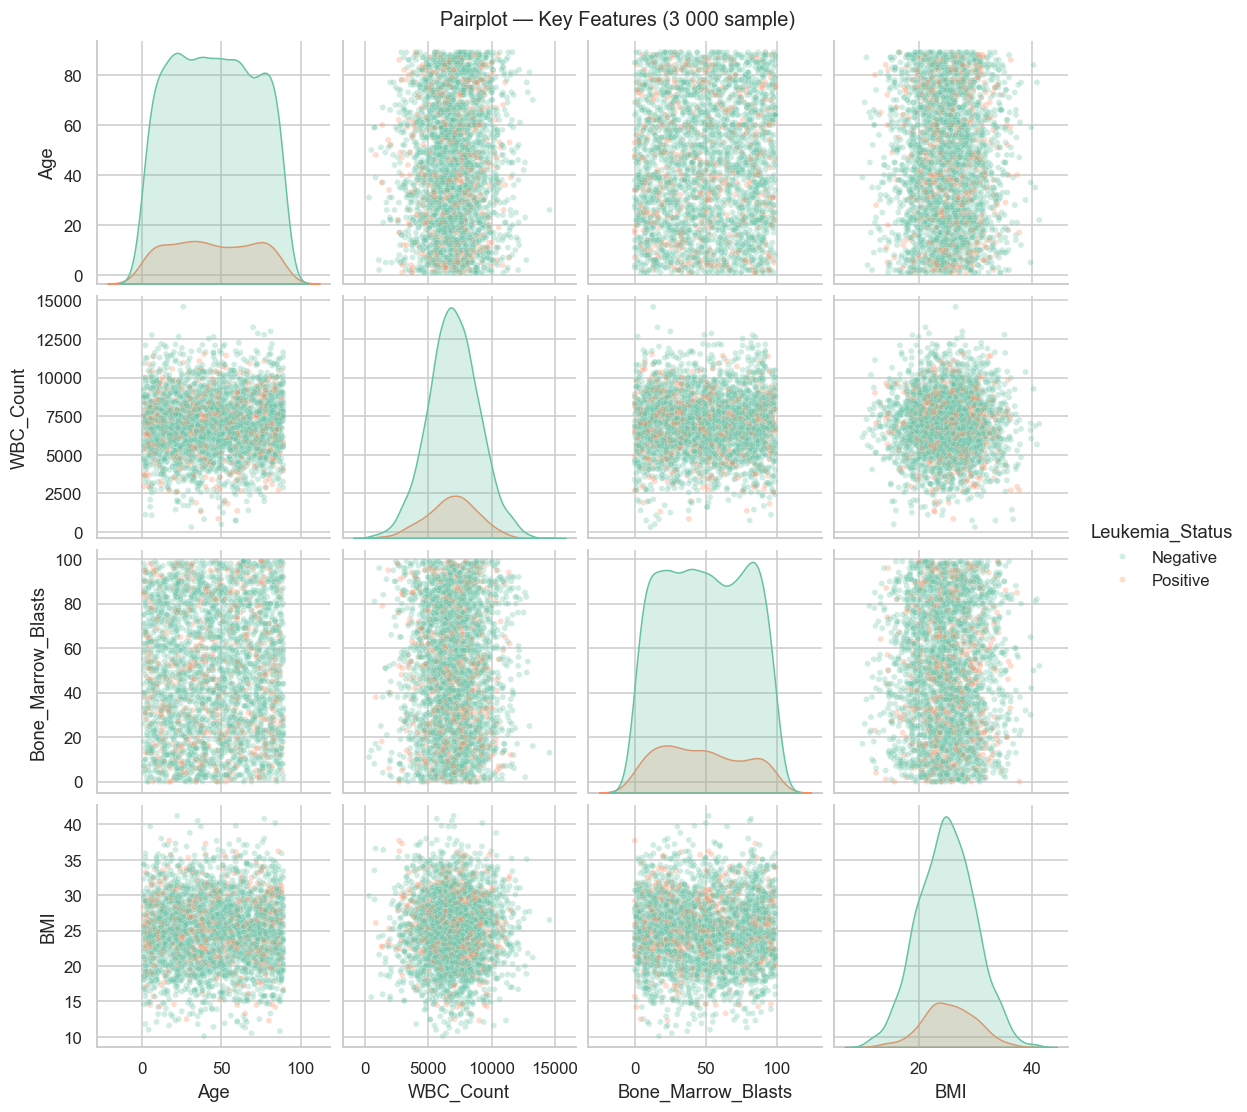

In [241]:
sample = df[['Age', 'WBC_Count', 'Bone_Marrow_Blasts', 'BMI', 'Leukemia_Status']].sample(3000, random_state=42)
g = sns.pairplot(sample, hue='Leukemia_Status', palette='Set2',
                 plot_kws={'alpha': 0.3, 's': 15}, diag_kind='kde')
g.figure.suptitle('Pairplot — Key Features (3 000 sample)', y=1.01, fontsize=13)
plt.show()

## 5. Data Cleaning

### 5.1 Missing Values

In [242]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal: {df.isnull().sum().sum()}')

Missing values per column:
Patient_ID              0
Age                     0
Gender                  0
Country                 0
WBC_Count               0
RBC_Count               0
Platelet_Count          0
Hemoglobin_Level        0
Bone_Marrow_Blasts      0
Genetic_Mutation        0
Family_History          0
Smoking_Status          0
Alcohol_Consumption     0
Radiation_Exposure      0
Infection_History       0
BMI                     0
Chronic_Illness         0
Immune_Disorders        0
Ethnicity               0
Socioeconomic_Status    0
Urban_Rural             0
Leukemia_Status         0
dtype: int64

Total: 0


### 5.2 Duplicate Detection & Removal

In [243]:
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after dedup: {df.shape}')

Duplicate rows: 0
Shape after dedup: (143194, 22)


### 5.3 Outlier Detection & Treatment (IQR Method)

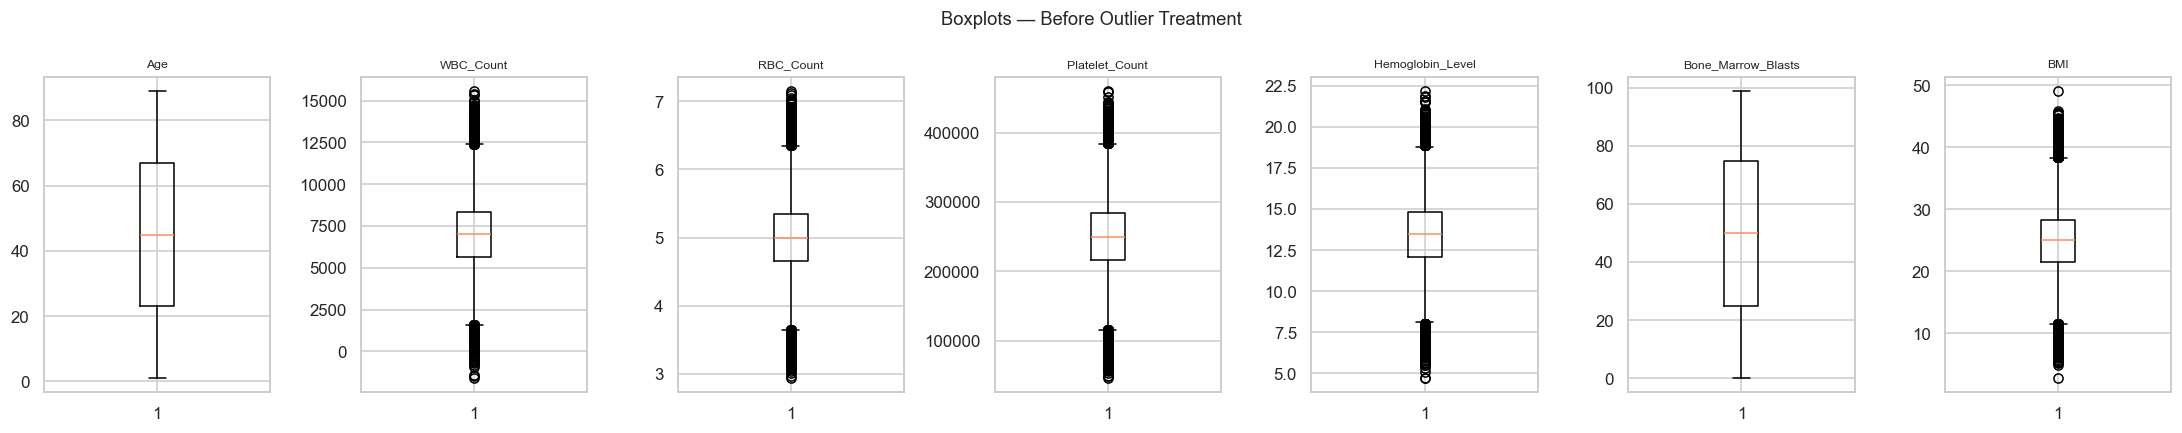

Outlier counts per column (IQR × 1.5):
  Age                            0 (0.00%)
  WBC_Count                    954 (0.67%)
  RBC_Count                    944 (0.66%)
  Platelet_Count              1042 (0.73%)
  Hemoglobin_Level             940 (0.66%)
  Bone_Marrow_Blasts             0 (0.00%)
  BMI                         1106 (0.77%)


In [244]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=8)
fig.suptitle('Boxplots — Before Outlier Treatment', fontsize=12)
plt.tight_layout()
plt.show()

print('Outlier counts per column (IQR × 1.5):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:<25} {n_out:>6} ({n_out/len(df)*100:.2f}%)')

In [245]:
# Cap outliers at 1st / 99th percentile (Winsorisation) to preserve data size
df_clean = df.copy()
for col in num_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower, upper)

print('Outlier treatment done (Winsorisation at 1st/99th percentile)')
print(f'Shape: {df_clean.shape}')

Outlier treatment done (Winsorisation at 1st/99th percentile)
Shape: (143194, 22)


### 5.4 Handling Mixed / Inconsistent Categorical Values

In [246]:
str_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

print('Stripped whitespace and title-cased all string columns.')
print('Leukemia_Status:', df_clean['Leukemia_Status'].unique())

Stripped whitespace and title-cased all string columns.
Leukemia_Status: ['Negative' 'Positive']


### 5.5 Drop Irrelevant Columns

In [247]:
df_clean = df_clean.drop(columns=['Patient_ID', 'Country'])
print(f'Columns after drop: {df_clean.shape[1]}')
print(df_clean.columns.tolist())

Columns after drop: 20
['Age', 'Gender', 'WBC_Count', 'RBC_Count', 'Platelet_Count', 'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'Genetic_Mutation', 'Family_History', 'Smoking_Status', 'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History', 'BMI', 'Chronic_Illness', 'Immune_Disorders', 'Ethnicity', 'Socioeconomic_Status', 'Urban_Rural', 'Leukemia_Status']


## 6. Feature Engineering & Encoding

### 6.1 Label Encoding — Binary Yes/No Columns

In [248]:
binary_yes_no = ['Genetic_Mutation', 'Family_History', 'Smoking_Status',
                 'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History',
                 'Chronic_Illness', 'Immune_Disorders']

for col in binary_yes_no:
    df_clean[col] = (df_clean[col] == 'Yes').astype(int)

print('Binary Yes/No -> 0/1 encoding done.')

Binary Yes/No -> 0/1 encoding done.


### 6.2 Label Encoding — Binary Two-Class Columns

In [249]:
df_clean['Gender'] = (df_clean['Gender'] == 'Male').astype(int)
df_clean['Urban_Rural'] = (df_clean['Urban_Rural'] == 'Urban').astype(int)
print('Gender (Male=1, Female=0) and Urban_Rural (Urban=1, Rural=0) encoded.')

Gender (Male=1, Female=0) and Urban_Rural (Urban=1, Rural=0) encoded.


### 6.3 Ordinal Encoding — Socioeconomic Status

In [250]:
ses_order = ['Low', 'Medium', 'High']
df_clean['Socioeconomic_Status'] = df_clean['Socioeconomic_Status'].map(
    {v: i for i, v in enumerate(ses_order)}
)
print('Socioeconomic_Status → Low=0, Medium=1, High=2')

Socioeconomic_Status → Low=0, Medium=1, High=2


### 6.4 One-Hot Encoding — Ethnicity

In [251]:
df_clean = pd.get_dummies(df_clean, columns=['Ethnicity'], drop_first=True, dtype=int)
print(f'After OHE — Shape: {df_clean.shape}')
print([c for c in df_clean.columns if 'Ethnicity' in c])

After OHE — Shape: (143194, 21)
['Ethnicity_Ethnic_Group_B', 'Ethnicity_Ethnic_Group_C']


### 6.5 Feature Construction — BMI Category & Age Bins

In [252]:
# BMI category (Underweight / Normal / Overweight / Obese)
df_clean['BMI_Category'] = pd.cut(
    df_clean['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]  # Underweight=0, Normal=1, Overweight=2, Obese=3
).astype(int)

# Age bins (Child / Young Adult / Middle-Aged / Senior)
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 18, 35, 60, 100],
    labels=[0, 1, 2, 3]  # Child=0, YoungAdult=1, MiddleAge=2, Senior=3
).astype(int)

print(f'New features added — BMI_Category, Age_Group')
print(f'Shape: {df_clean.shape}')

New features added — BMI_Category, Age_Group
Shape: (143194, 23)


### 6.6 Binarization — WBC_Count (High WBC is clinically relevant)

In [253]:
wbc_threshold = df_clean['WBC_Count'].median()
df_clean['WBC_High'] = (df_clean['WBC_Count'] > wbc_threshold).astype(int)
print(f'WBC_High binarised at median threshold: {wbc_threshold:.0f}')

WBC_High binarised at median threshold: 7007


### 6.7 Power Transformation — Handling Skewed Distributions

In [254]:
from sklearn.preprocessing import PowerTransformer

skewed_cols = ['WBC_Count', 'Platelet_Count']
pt = PowerTransformer(method='yeo-johnson')
df_clean[skewed_cols] = pt.fit_transform(df_clean[skewed_cols])

print('Yeo-Johnson power transform applied to:', skewed_cols)
for col in skewed_cols:
    print(f'  {col} skew after transform: {df_clean[col].skew():.3f}')

Yeo-Johnson power transform applied to: ['WBC_Count', 'Platelet_Count']
  WBC_Count skew after transform: -0.036
  Platelet_Count skew after transform: -0.023


### 6.8 Encode Target

In [255]:
df_clean['Leukemia_Status'] = (df_clean['Leukemia_Status'] == 'Positive').astype(int)
print('Target — Positive=1, Negative=0')
print(df_clean['Leukemia_Status'].value_counts())

Target — Positive=1, Negative=0
Leukemia_Status
0    121797
1     21397
Name: count, dtype: int64


In [256]:
df_clean.head()

,Age,Gender,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,...,Chronic_Illness,Immune_Disorders,Socioeconomic_Status,Urban_Rural,Leukemia_Status,Ethnicity_Ethnic_Group_B,Ethnicity_Ethnic_Group_C,BMI_Category,Age_Group,WBC_High
0,52,1,-2.207936,5.36,0.257349,12.2,72,1,0,1,...,0,0,0,0,0,1,0,1,2,0
1,15,0,-1.086884,4.81,0.571484,11.9,97,1,0,0,...,0,0,0,1,1,0,0,2,0,0
2,72,1,1.319261,5.17,1.422787,13.4,94,0,1,0,...,0,0,0,1,0,1,0,2,3,1
3,61,1,-0.360920,5.41,-0.709300,11.6,50,0,0,1,...,0,0,1,0,0,0,0,3,3,0
4,21,1,0.681966,4.78,1.210043,14.3,28,0,0,1,...,0,0,0,0,0,1,0,1,1,1


## 7. Feature Scaling (Standardisation)

In [257]:
X = df_clean.drop(columns='Leukemia_Status')
y = df_clean['Leukemia_Status']

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape        : {y.shape}')
print('\nFinal features:')
print(X.columns.tolist())

Feature matrix shape: (143194, 23)
Target shape        : (143194,)

Final features:
['Age', 'Gender', 'WBC_Count', 'RBC_Count', 'Platelet_Count', 'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'Genetic_Mutation', 'Family_History', 'Smoking_Status', 'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History', 'BMI', 'Chronic_Illness', 'Immune_Disorders', 'Socioeconomic_Status', 'Urban_Rural', 'Ethnicity_Ethnic_Group_B', 'Ethnicity_Ethnic_Group_C', 'BMI_Category', 'Age_Group', 'WBC_High']


In [258]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

Train: (114555, 23) | Test: (28639, 23)
Train class balance: {0: 97437, 1: 17118}


## 8. Smart Pipeline — Auto-Selects Best Model

In [259]:
# Columns that need scaling (continuous numerical)
scale_cols = ['Age', 'WBC_Count', 'RBC_Count', 'Platelet_Count',
              'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'BMI']
# Remaining features are already binary/ordinal — no scaling needed
passthrough_cols = [c for c in X.columns if c not in scale_cols]

preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), scale_cols),
    ('pass',  'passthrough',   passthrough_cols)
])

model_configs = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([('preprocessor', preprocessor), ('model', clf)])
    for name, clf in model_configs.items()
}

print('Pipelines built for:', list(pipelines.keys()))

Pipelines built for: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [260]:
results = {}

for name, pipe in pipelines.items():
    print(f'Training {name} ...', end=' ')
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_prob  = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'pipeline': pipe,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'acc'    : accuracy_score(y_test, y_pred),
        'f1'     : f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }
    print(f"ROC-AUC={results[name]['roc_auc']:.4f}  F1={results[name]['f1']:.4f}")

Training Logistic Regression ... ROC-AUC=0.4939  F1=0.2264
Training Decision Tree ... ROC-AUC=0.5041  F1=0.2088
Training Random Forest ... ROC-AUC=0.5019  F1=0.0727


## 9. Model Comparison

In [261]:
summary = pd.DataFrame({
    name: {
        'Accuracy' : round(r['acc'],    4),
        'F1-Score' : round(r['f1'],     4),
        'ROC-AUC'  : round(r['roc_auc'],4),
    }
    for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print(summary.to_string())
summary

                     Accuracy  F1-Score  ROC-AUC
Decision Tree          0.6313    0.2088   0.5041
Random Forest          0.8129    0.0727   0.5019
Logistic Regression    0.5085    0.2264   0.4939


,Accuracy,F1-Score,ROC-AUC
Decision Tree,0.6313,0.2088,0.5041
Random Forest,0.8129,0.0727,0.5019
Logistic Regression,0.5085,0.2264,0.4939


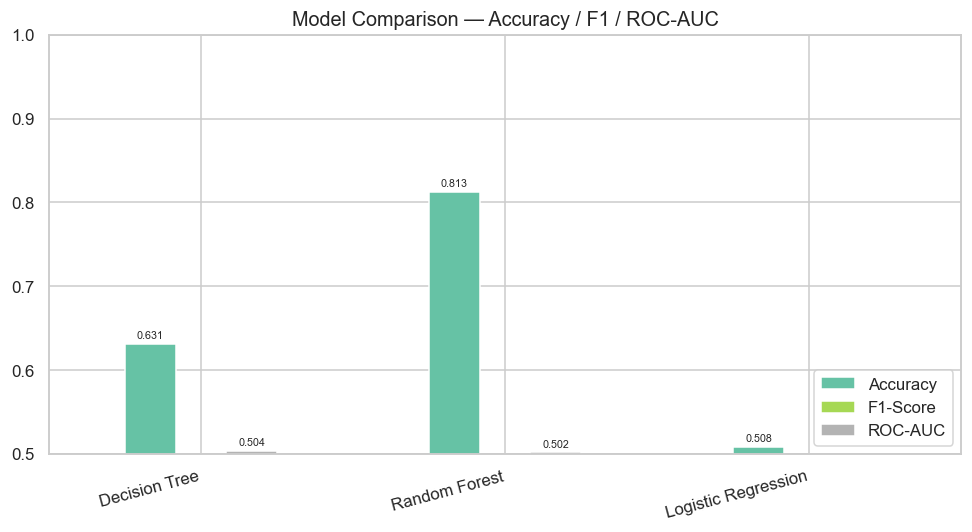

In [262]:
fig, ax = plt.subplots(figsize=(9, 5))
summary[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax, edgecolor='white', colormap='Set2'
)
ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(summary.index, rotation=15, ha='right')
ax.set_title('Model Comparison — Accuracy / F1 / ROC-AUC', fontsize=13)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

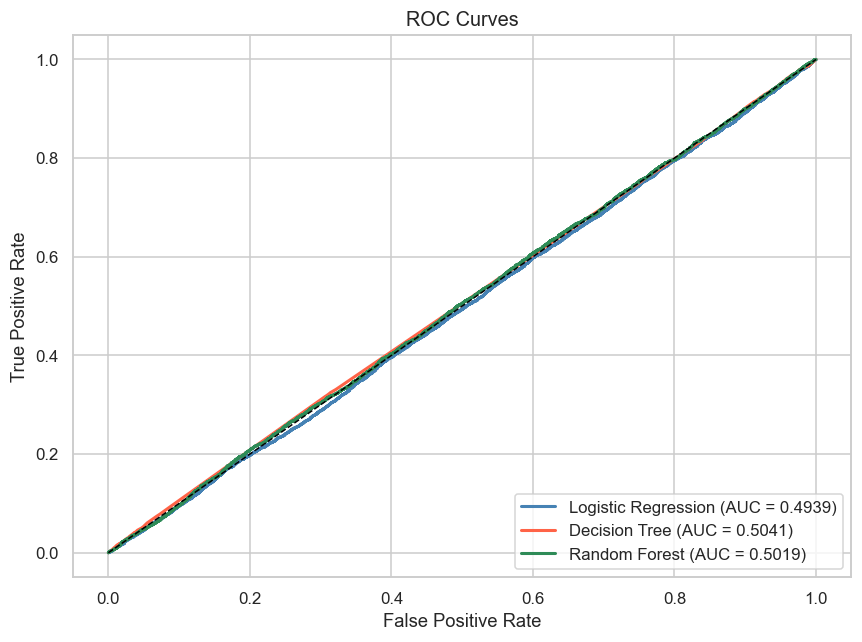

In [263]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'seagreen']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {r['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

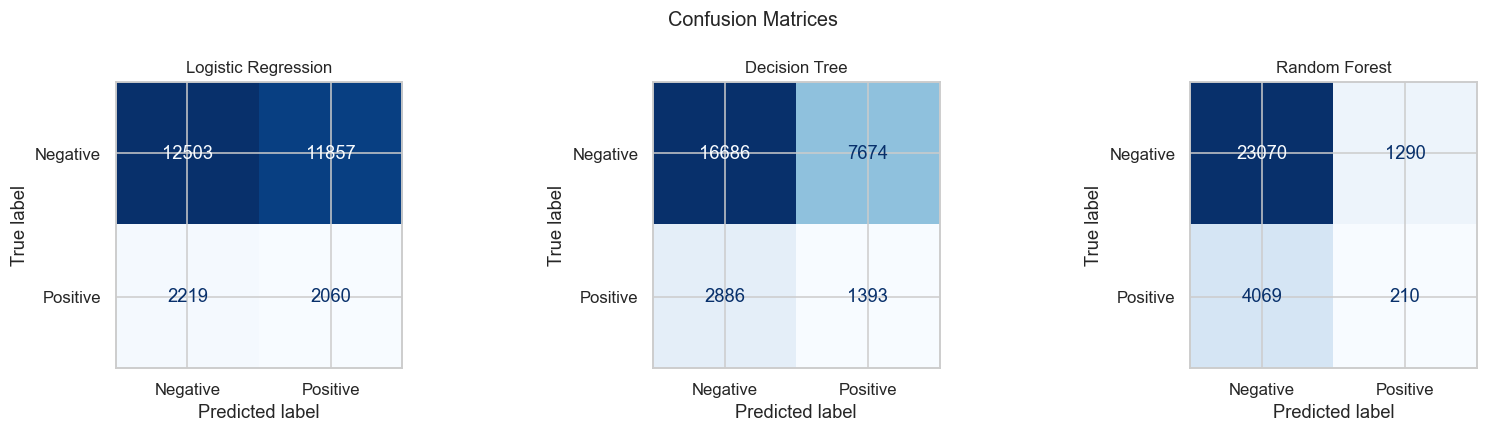

In [264]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'],
        display_labels=['Negative', 'Positive'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Decision Tree & Random Forest)

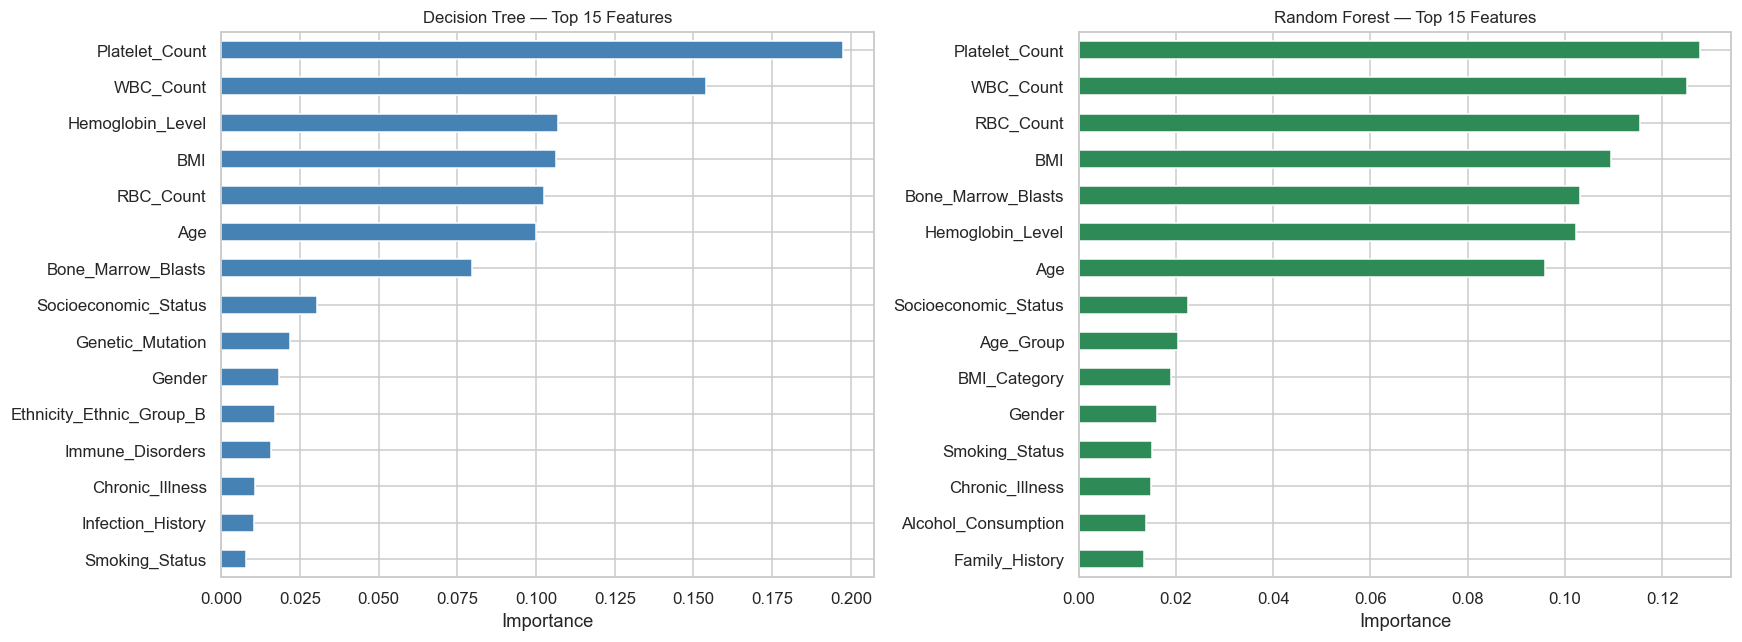

In [265]:
feature_names = (
    scale_cols
    + passthrough_cols
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ['Decision Tree', 'Random Forest']):
    model = results[model_name]['pipeline'].named_steps['model']
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.sort_values(ascending=True).tail(15).plot(
        kind='barh', ax=ax, color='steelblue' if model_name == 'Decision Tree' else 'seagreen'
    )
    ax.set_title(f'{model_name} — Top 15 Features', fontsize=11)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 11. Cross-Validation — All Models

Logistic Regression    CV ROC-AUC: 0.4949 ± 0.0024
Decision Tree          CV ROC-AUC: 0.4992 ± 0.0062
Random Forest          CV ROC-AUC: 0.5005 ± 0.0038


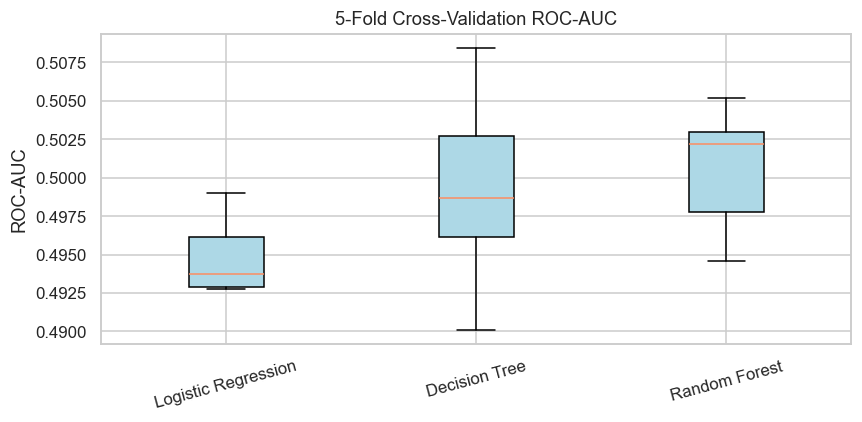

In [266]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_results[n] for n in cv_results], labels=list(cv_results.keys()), patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('5-Fold Cross-Validation ROC-AUC', fontsize=12)
ax.set_ylabel('ROC-AUC')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 12. Best Model Selection & Final Report

In [267]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_result     = results[best_model_name]
best_pipeline   = best_result['pipeline']

print(f'BEST MODEL : {best_model_name}')
print(f'  Accuracy  : {best_result["acc"]:.4f}')
print(f'  F1-Score  : {best_result["f1"]:.4f}')
print(f'  ROC-AUC   : {best_result["roc_auc"]:.4f}')
print()
print(classification_report(y_test, best_result['y_pred'], target_names=['Negative', 'Positive']))

BEST MODEL : Decision Tree
  Accuracy  : 0.6313
  F1-Score  : 0.2088
  ROC-AUC   : 0.5041

              precision    recall  f1-score   support

    Negative       0.85      0.68      0.76     24360
    Positive       0.15      0.33      0.21      4279

    accuracy                           0.63     28639
   macro avg       0.50      0.51      0.48     28639
weighted avg       0.75      0.63      0.68     28639



In [268]:
print(f'The winning pipeline is stored in `best_pipeline` and ready for inference.')
print(f'Steps: {[step[0] for step in best_pipeline.steps]}')

The winning pipeline is stored in `best_pipeline` and ready for inference.
Steps: ['preprocessor', 'model']


## Summary

| Step | Action |
|------|--------|
| Missing Values | None found |
| Duplicates | Removed |
| Outliers | Winsorised at 1st / 99th percentile |
| String Cleaning | Strip + Title-case |
| Dropped Columns | Patient_ID, Country |
| Binary Encoding | Yes/No, Gender, Urban_Rural |
| Ordinal Encoding | Socioeconomic_Status |
| One-Hot Encoding | Ethnicity |
| Feature Construction | BMI_Category, Age_Group, WBC_High |
| Power Transform | WBC_Count, Platelet_Count (Yeo-Johnson) |
| Scaling | StandardScaler inside ColumnTransformer |
| Models Tried | Logistic Regression, Decision Tree, Random Forest |
| Best Model | **Auto-selected by highest ROC-AUC** |